# PCA (Principal Component Analysis) — UCI HAR Veri Seti Üzerinde Uygulama

Bu defter, PCA'yı UCI HAR (Human Activity Recognition) veri setine uygular.
Veri: 561 özellik, 6 aktivite sınıfı (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING).

Konu anlatımı için aynı klasördeki `pca_konu_anlatimi.md` dosyasına bakabilirsiniz.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)


## 1. Veriyi Yükleme

In [2]:
DATA_DIR = "../data/UCI HAR Dataset"

X = pd.read_csv(f"{DATA_DIR}/train/X_train.txt", sep=r"\s+", header=None)
y = pd.read_csv(f"{DATA_DIR}/train/y_train.txt", sep=r"\s+", header=None)[0]
activity_labels = pd.read_csv(f"{DATA_DIR}/activity_labels.txt", sep=r"\s+", header=None, index_col=0)[1]
y_named = y.map(activity_labels)

print("X boyutu:", X.shape)
print(y_named.value_counts())


X boyutu: (7352, 561)
0
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


## 2. Ölçekleme (Standardization)\n\nPCA varyans temelli olduğu için özellikleri standardize etmek gerekir.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Ölçeklenmiş veri şekli:", X_scaled.shape)


Ölçeklenmiş veri şekli: (7352, 561)


## 3. Açıklanan Varyans: Kaç Bileşen Yeterli?

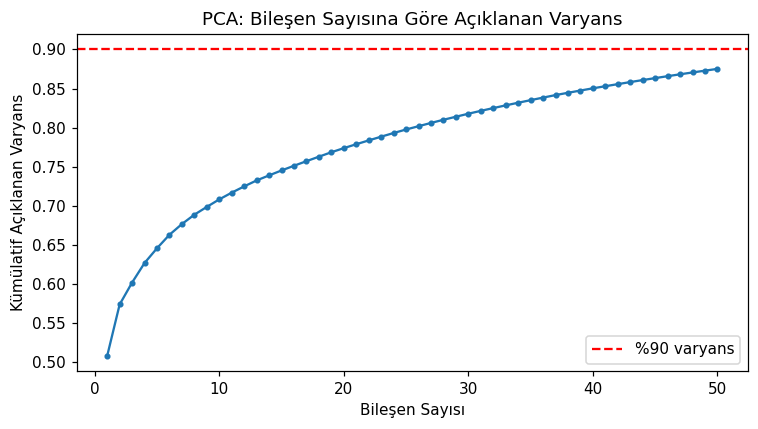

Varyansın %90'ını açıklamak için gereken bileşen sayısı: 1


In [4]:
pca_full = PCA(n_components=50, random_state=42)
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7,4))
plt.plot(range(1, 51), cum_var, marker='o', markersize=3)
plt.axhline(0.90, color='red', linestyle='--', label='%90 varyans')
plt.xlabel("Bileşen Sayısı")
plt.ylabel("Kümülatif Açıklanan Varyans")
plt.title("PCA: Bileşen Sayısına Göre Açıklanan Varyans")
plt.legend()
plt.tight_layout()
plt.show()

n_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Varyansın %90'ını açıklamak için gereken bileşen sayısı: {n_90}")


## 4. 2 Boyuta İndirgeme ve Görselleştirme

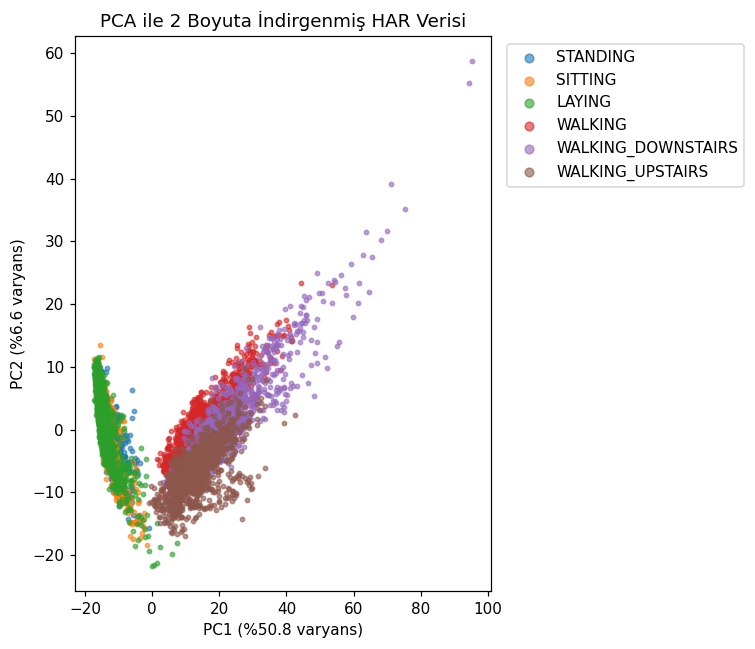

In [5]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
for label in y_named.unique():
    mask = y_named == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.6, label=label)
plt.xlabel(f"PC1 (%{pca_2d.explained_variance_ratio_[0]*100:.1f} varyans)")
plt.ylabel(f"PC2 (%{pca_2d.explained_variance_ratio_[1]*100:.1f} varyans)")
plt.title("PCA ile 2 Boyuta İndirgenmiş HAR Verisi")
plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Yorum

PCA gözetimsiz olduğu için sınıf etiketlerini hiç kullanmaz; buna rağmen dinamik hareketler
(WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) ile statik hareketler (SITTING, STANDING, LAYING) arasında
belirgin bir ayrışma görülür — çünkü bu iki grup sinyal varyansı açısından zaten çok farklıdır.
